## Phase 1: Exploratory Data Analysis (EDA)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import warnings
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

In [4]:
df = pd.read_csv("AIML Dataset.csv")
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB


In [6]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='str')

In [7]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [8]:
df["isFlaggedFraud"].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

In [9]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [10]:
df.isnull().sum().sum()

np.int64(0)

In [11]:
df.shape

(6362620, 11)

In [12]:
df.shape[0]  # number of rows and all samples

6362620

In [13]:
percentage_of_fraud = (df["isFraud"].value_counts()[1] / df.shape[0]) * 100
print(f"Percentage of fraudulent transactions: {percentage_of_fraud:.2f}%")

Percentage of fraudulent transactions: 0.13%


In [14]:
df["type"].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

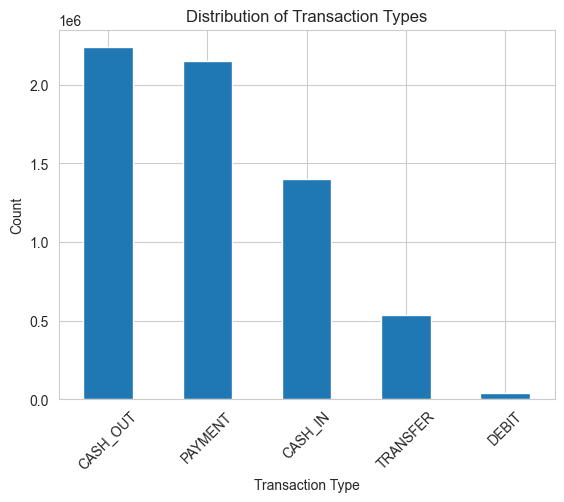

In [15]:
df["type"].value_counts().plot(kind="bar")
plt.title("Distribution of Transaction Types")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [16]:
frauds_by_type = df[df["isFraud"] == 1]["type"].value_counts()
frauds_by_type


type
CASH_OUT    4116
TRANSFER    4097
Name: count, dtype: int64

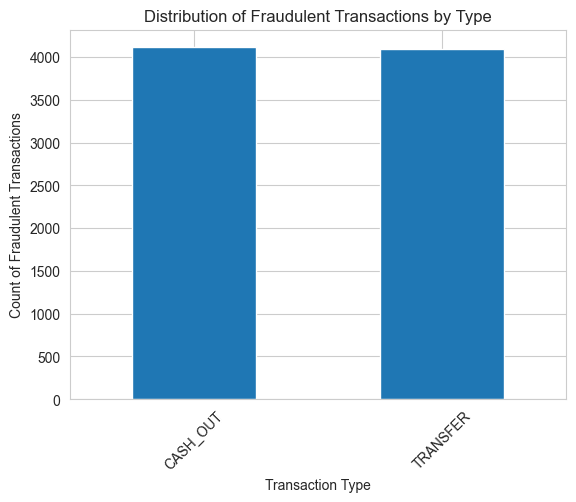

In [17]:
frauds_by_type = df[df["isFraud"] == 1]["type"].value_counts()
frauds_by_type.plot(kind="bar")
plt.title("Distribution of Fraudulent Transactions by Type")
plt.xlabel("Transaction Type")
plt.ylabel("Count of Fraudulent Transactions")
plt.xticks(rotation=45)
plt.show()

In [18]:
frauds_by_type = df.groupby("type")["isFraud"].mean().sort_values(ascending=False)
frauds_by_type

type
TRANSFER    0.007688
CASH_OUT    0.001840
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64

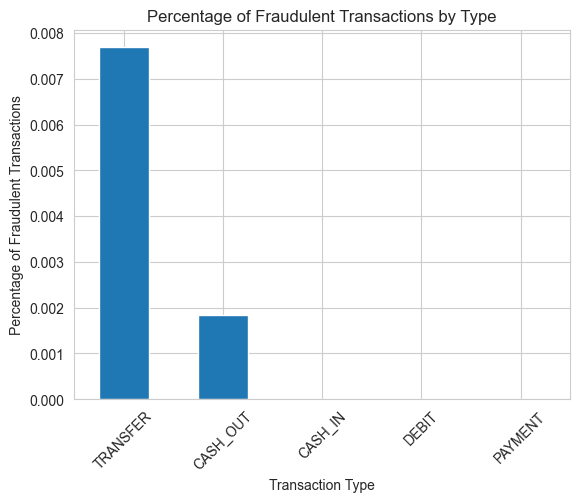

In [19]:
frauds_by_type = df.groupby("type")["isFraud"].mean().sort_values(ascending=False)
frauds_by_type.plot(kind="bar")
plt.title("Percentage of Fraudulent Transactions by Type")
plt.xlabel("Transaction Type")
plt.ylabel("Percentage of Fraudulent Transactions")
plt.xticks(rotation=45)
plt.show()

In [20]:
df["amount"].describe().astype(int)

count     6362620
mean       179861
std        603858
min             0
25%         13389
50%         74871
75%        208721
max      92445516
Name: amount, dtype: int64

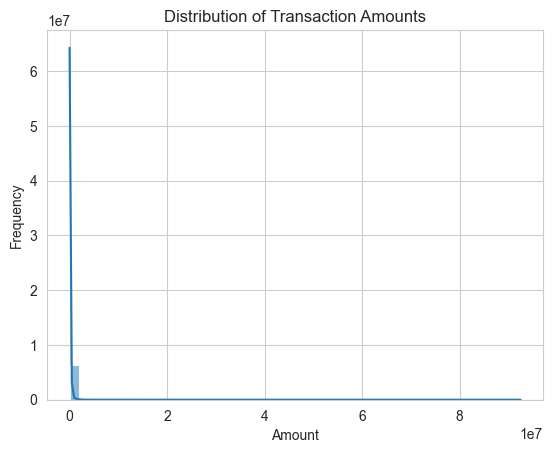

In [21]:
sns.histplot(df["amount"], bins=50, kde=True)
plt.title("Distribution of Transaction Amounts")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

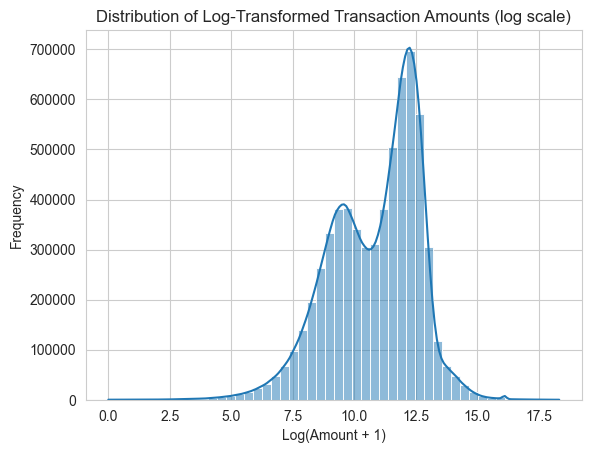

In [22]:
sns.histplot(np.log1p(df["amount"]), bins=50, kde=True) # log transformation to handle skewness
plt.title("Distribution of Log-Transformed Transaction Amounts (log scale)")
plt.xlabel("Log(Amount + 1)")
plt.ylabel("Frequency")
plt.show()

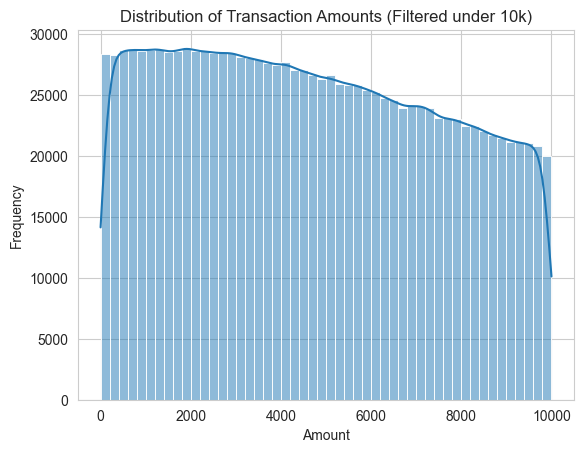

In [23]:
data = df["amount"] < 10000 # filter out transactions with amount less than 10,000
sns.histplot(x=df[data]["amount"], bins=50, kde=True)
plt.title("Distribution of Transaction Amounts (Filtered under 10k)")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

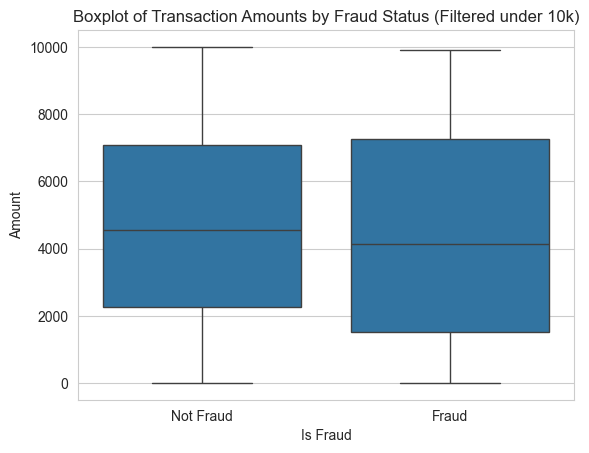

In [24]:
data = df["amount"] < 10000 # filter out transactions with amount less than 10,000
sns.boxplot(data=df[data], x="isFraud", y="amount")
plt.title("Boxplot of Transaction Amounts by Fraud Status (Filtered under 10k)")
plt.xlabel("Is Fraud")
plt.ylabel("Amount")
plt.xticks([0, 1], ["Not Fraud", "Fraud"])
plt.show()

In [ ]:
df["balanceDiffOriginal"] = df["oldbalanceOrg"] - df["newbalanceOrig"]
df["balanceDiffDestination"] = df["newbalanceDest"] - df["oldbalanceDest"]

In [26]:
(df["balanceDiffOriginal"]< 0).sum()  # count of transactions where original balance decreased

np.int64(1399253)

In [27]:
(df["balanceDiffDestination"] < 0).sum()  # count of transactions where destination balance decreased

np.int64(1238864)

In [28]:
df.head()


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOriginal,balanceDiffDestination
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


In [32]:
frauds_by_step = df[df["isFraud"] == 1]["step"].value_counts().sort_index()

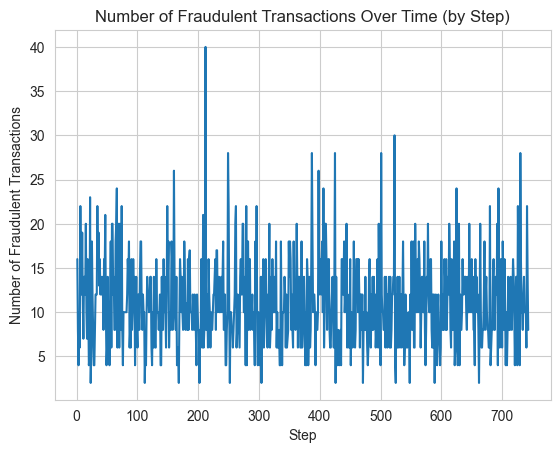

In [35]:
plt.plot(frauds_by_step.index, frauds_by_step.values, label="Fraudulent Transactions")
plt.title("Number of Fraudulent Transactions Over Time (by Step)")
plt.xlabel("Step")
plt.ylabel("Number of Fraudulent Transactions")
plt.show()

In [36]:
# No need for step column as it doesn't provide meaningful insights for fraud detection in this dataset.
df = df.drop(columns=["step"])
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOriginal,balanceDiffDestination
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


In [39]:
top_senders = df["nameOrig"].value_counts().head(10)
top_senders

nameOrig
C2098525306    3
C400299098     3
C1999539787    3
C1065307291    3
C545315117     3
C1976208114    3
C1784010646    3
C1530544995    3
C1902386530    3
C1677795071    3
Name: count, dtype: int64

In [40]:
top_recipients = df["nameDest"].value_counts().head(10)
top_recipients

nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
C1590550415    101
C451111351      99
C1789550256     99
C1360767589     98
C1023714065     97
Name: count, dtype: int64

In [42]:
# How to get top 10 fraudulent senders and recipients
fraudulent_senders = df[df["isFraud"] == 1]["nameOrig"].value_counts().head(10)
fraudulent_recipients = df[df["isFraud"] == 1]["nameDest"].value_counts().head(10)

print(fraudulent_senders)
fraudulent_recipients

nameOrig
C1305486145    1
C840083671     1
C1420196421    1
C2101527076    1
C137533655     1
C1118430673    1
C749981943     1
C1334405552    1
C467632528     1
C1364127192    1
Name: count, dtype: int64


nameDest
C410033330     2
C803116137     2
C904300960     2
C1013511446    2
C2020337583    2
C200064275     2
C185805228     2
C52390890      2
C935310781     2
C1827219533    2
Name: count, dtype: int64

In [49]:
frauds_types = df[df["type"].isin(["TRANSFER", "CASH_OUT"])]

In [50]:
frauds_types["type"].value_counts()

type
CASH_OUT    2237500
TRANSFER     532909
Name: count, dtype: int64

In [54]:
frauds_types = df[df["type"].isin(["TRANSFER", "CASH_OUT"])]["isFraud"].value_counts()

frauds_types

isFraud
0    2762196
1       8213
Name: count, dtype: int64

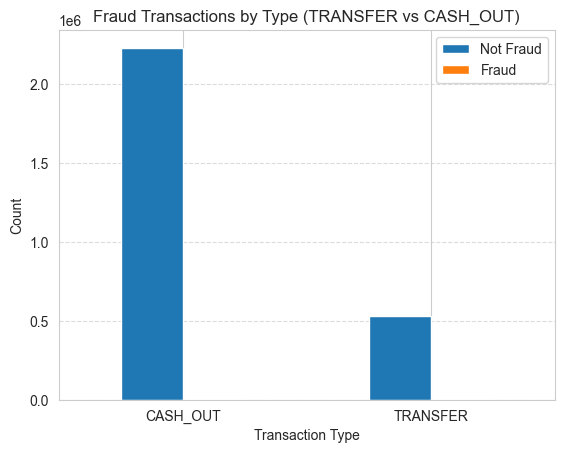

In [63]:
frauds_types = df[df["type"].isin(["TRANSFER", "CASH_OUT"])].groupby(["type", "isFraud"]).size().unstack(fill_value=0)

frauds_types.plot(kind="bar")
plt.title("Fraud Transactions by Type (TRANSFER vs CASH_OUT)")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend(labels=["Not Fraud", "Fraud"])
plt.grid(True, axis="y", linestyle="--", alpha=0.7)
plt.show()

The following plot shows only the fraudulent transactions for TRANSFER and CASH_OUT types, making the fraud counts visible. Since fraud is rare (only 0.13% of transactions), filtering to show only frauds ensures the bars are prominent.

In [66]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [67]:
df[df["type"].isin(["TRANSFER", "CASH_OUT"])]["isFraud"].value_counts()

isFraud
0    2762196
1       8213
Name: count, dtype: int64

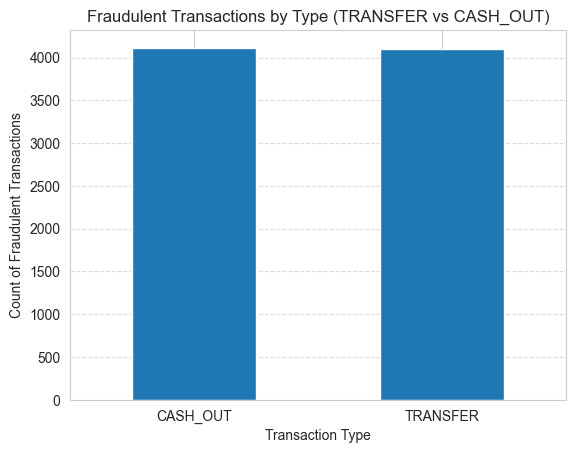

In [62]:
frauds_types = df[(df["type"].isin(["TRANSFER", "CASH_OUT"])) & (df["isFraud"] == 1)].groupby("type").size()

frauds_types.plot(kind="bar")
plt.title("Fraudulent Transactions by Type (TRANSFER vs CASH_OUT)")
plt.xlabel("Transaction Type")
plt.ylabel("Count of Fraudulent Transactions")
plt.xticks(rotation=0)
plt.grid(True, axis="y", linestyle="--", alpha=0.7)
plt.show()

In [140]:
# Correlation between amount and fraud
correlation = df[["amount", "isFraud"]].corr()
print(correlation)

ModuleNotFoundError: No module named 'xgboost'

In [72]:
# Correlation Matrix
correlation_matrix = df[["amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest", "isFraud"]].corr()

In [73]:
correlation_matrix

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
amount,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.076688
oldbalanceOrg,-0.002762,1.000000,0.998803,0.066243,0.042029,0.010154
newbalanceOrig,-0.007861,0.998803,1.000000,0.067812,0.041837,-0.008148
oldbalanceDest,0.294137,0.066243,0.067812,1.000000,0.976569,-0.005885
newbalanceDest,0.459304,0.042029,0.041837,0.976569,1.000000,0.000535
isFraud,0.076688,0.010154,-0.008148,-0.005885,0.000535,1.000000


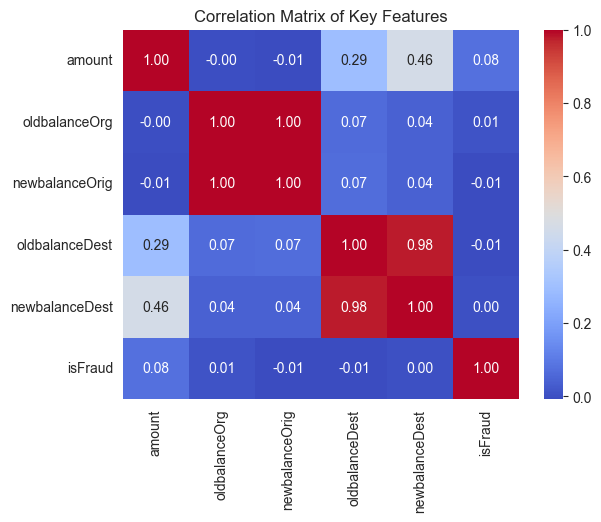

In [74]:
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Key Features")
plt.show()

In [88]:
zero_balance_after_transaction = df[(df["oldbalanceOrg"] > 0) & (df["newbalanceOrig"] == 0)]
zero_balance_after_transaction = zero_balance_after_transaction[zero_balance_after_transaction["type"].isin(["TRANSFER", "CASH_OUT"])]

print(f"Number of transactions where original balance goes to zero after transaction: {zero_balance_after_transaction.shape[0]}")

Number of transactions where original balance goes to zero after transaction: 1188074


In [89]:
zero_balance_after_transaction.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOriginal,balanceDiffDestination
2,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1,0,181.0,0.00
3,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1,0,181.0,-21182.00
15,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0,0,15325.0,46430.44
19,TRANSFER,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0,0,705.0,-22425.00
24,TRANSFER,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0,0,10835.0,2712905.89


## Phase 2: Feature Engineering and ML Pipeline

In [148]:
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer # for handling different types of features (numerical and categorical)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

In [107]:
df_model = df.copy()
df_model.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOriginal,balanceDiffDestination
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


In [108]:
df_model.drop(columns=["nameOrig", "nameDest", "isFlaggedFraud"], inplace=True)

### Feature Engineering

In [109]:
# Types of Data:
# - Numerical: amount, oldbalanceOrg, newbalanceOrig, oldbalanceDest, newbalanceDest, balanceDiffOriginal, balanceDiffDestination
# - Categorical: type

numerical_features = ["amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest", "balanceDiffOriginal", "balanceDiffDestination"]
categorical_features = ["type"]

In [110]:
y = df_model["isFraud"]
X = df_model.drop(columns=["isFraud"])

In [111]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [112]:
# Preprocessing and modeling pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first'),categorical_features)
    ],remainder='drop'
)

### Train Logistic Regression Model:

In [113]:
model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))
])

In [114]:
model_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [115]:
y_pred = model_pipeline.predict(X_test)

### Evaluation Metrices

In [116]:
classification_report(y_test, y_pred)

'              precision    recall  f1-score   support\n\n           0       1.00      0.95      0.97   1270881\n           1       0.02      0.94      0.04      1643\n\n    accuracy                           0.95   1272524\n   macro avg       0.51      0.95      0.51   1272524\nweighted avg       1.00      0.95      0.97   1272524\n'

In [123]:
classification_rep = classification_report(y_test, y_pred)
print("Classification Report:\n", classification_rep)

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.95      0.97   1270881
           1       0.02      0.94      0.04      1643

    accuracy                           0.95   1272524
   macro avg       0.51      0.95      0.51   1272524
weighted avg       1.00      0.95      0.97   1272524



In [128]:
confusion_matrix(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[1203137   67744]
 [     93    1550]]


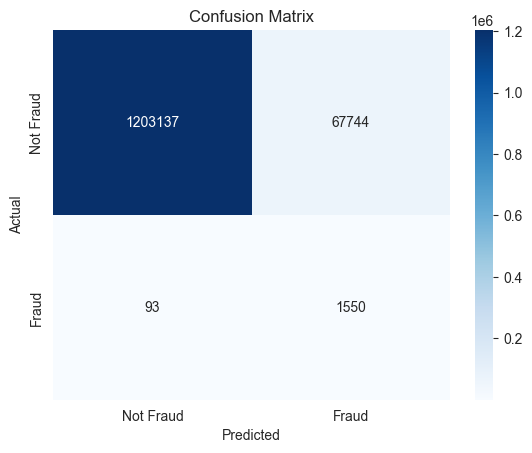

In [122]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
			xticklabels=["Not Fraud", "Fraud"],
			yticklabels=["Not Fraud", "Fraud"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# How to calculate and visualize ROC AUC
y_prob = model_pipeline.predict_proba(X_test)[:, 1]  # Get probabilities
print(y_prob[:10])  # Print the first 10 predicted probabilities for the positive class (fraud)
roc_auc = roc_auc_score(y_test, y_prob) # Calculate ROC AUC score (Receiver Operating Characteristic - Area Under the Curve)
print(f"ROC AUC Score: {roc_auc:.4f}")


[4.55882446e-05 7.81388080e-08 2.41254779e-14 ... 2.10787729e-08
 8.96328648e-02 1.45228830e-01]
ROC AUC Score: 0.9901


Text(0.5, 1.0, 'ROC Curve')

Text(0.5, 1.0, 'ROC Curve')

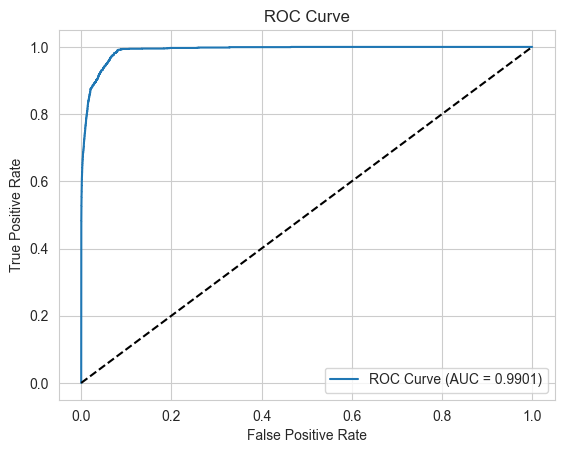

In [137]:
# Visualize ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob) # Calculate false positive rate, true positive rate, and thresholds for ROC curve
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line for reference
plt.title("ROC Curve")

In [139]:
score = model_pipeline.score(X_test, y_test) * 100 
print(f"Model Accuracy: {score:.2f}%")

Model Accuracy: 94.67%


### Random Forest Model:

In [146]:
# Prepare data
# I will use the same X and y from the previous logistic regression model, which are already defined as:

# y = df["isFraud"]
# X = df.drop(columns=["isFraud", "step", "nameOrig", "nameDest"])

numerical_features = ["amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest", "balanceDiffOriginal", "balanceDiffDestination"]
categorical_features = ["type"]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first'),categorical_features)
    ],remainder='drop'
)


In [ ]:
# Random Forest
rf_pipeline = Pipeline([
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1))
])


In [ ]:
rf_pipeline.fit(X_train, y_train)

In [168]:
y_pred_rf = rf_pipeline.predict(X_test)
y_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

### Evaluation Metrices

In [169]:
print("Random Forest classification report:\n", classification_report(y_test, y_pred_rf, digits=4))
print("Random Forest ROC AUC:", roc_auc_score(y_test, y_proba_rf))
print("Random Forest confusion matrix:\n", confusion_matrix(y_test, y_pred_rf))


Random Forest classification report:
               precision    recall  f1-score   support

           0     0.9998    1.0000    0.9999   1270881
           1     0.9629    0.8211    0.8863      1643

    accuracy                         0.9997   1272524
   macro avg     0.9813    0.9105    0.9431   1272524
weighted avg     0.9997    0.9997    0.9997   1272524

Random Forest ROC AUC: 0.9981133493536107
Random Forest confusion matrix:
 [[1270829      52]
 [    294    1349]]


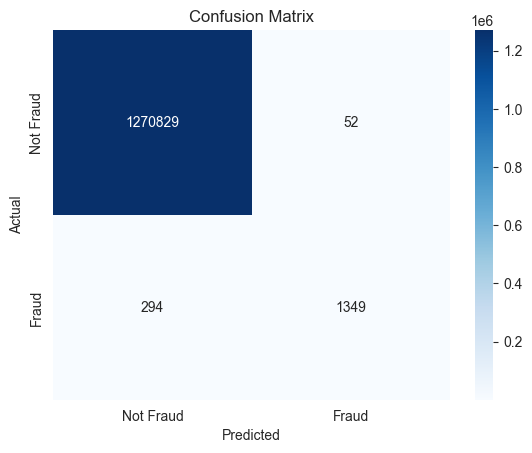

In [150]:
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
			xticklabels=["Not Fraud", "Fraud"],
			yticklabels=["Not Fraud", "Fraud"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

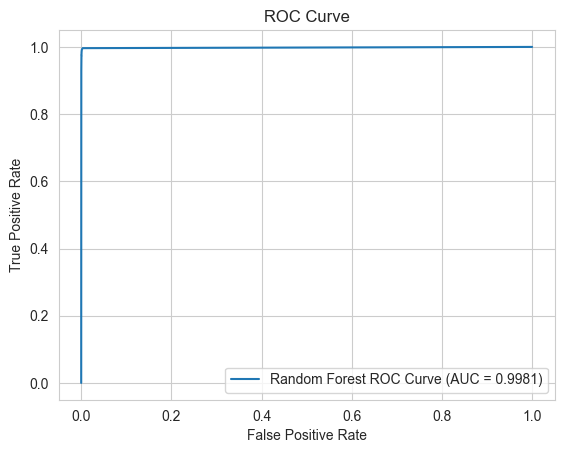

In [151]:
roc_auc_rf = roc_auc_score(y_test, y_proba_rf)
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_proba_rf)
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest ROC Curve (AUC = {roc_auc_rf:.4f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [152]:
score = rf_pipeline.score(X_test, y_test) * 100 
print(f"Model Accuracy: {score:.2f}%")

Model Accuracy: 99.97%


### XGBoost Model:

In [154]:
# Prepare data
# I will use the same X and y from the previous logistic regression model, which are already defined as:

# y = df["isFraud"]
# X = df.drop(columns=["isFraud", "step", "nameOrig", "nameDest"])

numerical_features = ["amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest", "balanceDiffOriginal", "balanceDiffDestination"]
categorical_features = ["type"]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first'),categorical_features)
    ],remainder='drop'
)


In [155]:
# Prepare data
# I will use the same X and y from the previous logistic regression model, which are already defined as:

# XGBoost
xgb_pipeline = Pipeline([
    ("prep", preprocessor),
    ("clf", xgb.XGBClassifier(use_label_encoder=False, eval_metric="logloss", scale_pos_weight=(y == 0).sum() / (y == 1).sum(),
                              n_estimators=200, max_depth=6, random_state=42, n_jobs=-1))
])


In [158]:
xgb_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

In [159]:
y_pred_xgb = xgb_pipeline.predict(X_test)
y_proba_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

print("XGBoost classification report:\n", classification_report(y_test, y_pred_xgb, digits=4))
print("XGBoost ROC AUC:", roc_auc_score(y_test, y_proba_xgb))
print("XGBoost confusion matrix:\n", confusion_matrix(y_test, y_pred_xgb))

XGBoost classification report:
               precision    recall  f1-score   support

           0     1.0000    0.9991    0.9995   1270881
           1     0.5814    0.9763    0.7288      1643

    accuracy                         0.9991   1272524
   macro avg     0.7907    0.9877    0.8641   1272524
weighted avg     0.9994    0.9991    0.9992   1272524

XGBoost ROC AUC: 0.9992162569693009
XGBoost confusion matrix:
 [[1269726    1155]
 [     39    1604]]


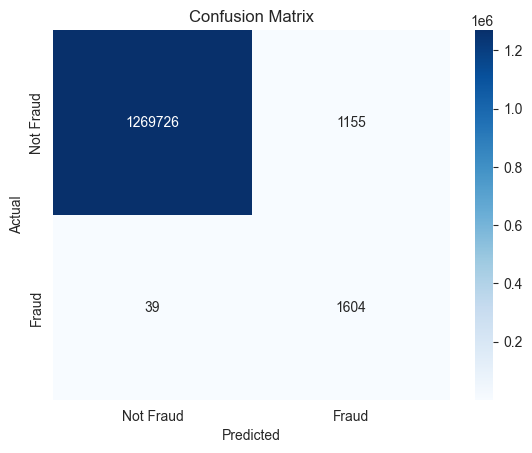

In [160]:
cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
			xticklabels=["Not Fraud", "Fraud"],
			yticklabels=["Not Fraud", "Fraud"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

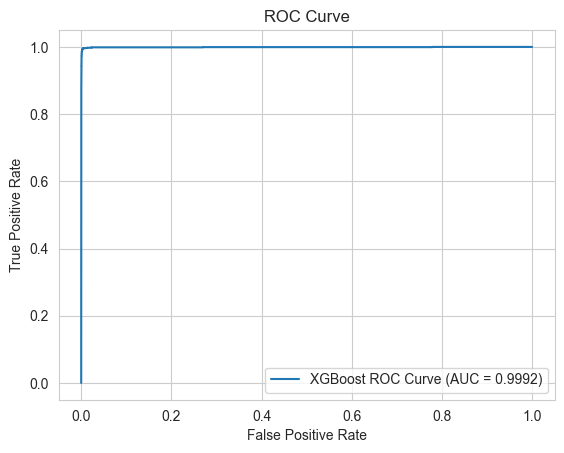

In [161]:
roc_auc_xgb = roc_auc_score(y_test, y_proba_xgb)
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, y_proba_xgb)
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost ROC Curve (AUC = {roc_auc_xgb:.4f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [162]:
score = xgb_pipeline.score(X_test, y_test) * 100 
print(f"Model Accuracy: {score:.2f}%")

Model Accuracy: 99.91%


## Phase 3: Save the Trained Model

In [165]:
# Save the model
import joblib

joblib.dump(model_pipeline, "lr_fraud_model.pkl")
joblib.dump(rf_pipeline, "rf_fraud_model.pkl")
joblib.dump(xgb_pipeline, "xgb_fraud_model.pkl")

['xgb_fraud_model.pkl']

In [167]:
# Test the model on a single transaction

trained_model = joblib.load("xgb_fraud_model.pkl")
sample_transaction = X_test.iloc[0:1]  # Take the first transaction from the test set
predicted_label = trained_model.predict(sample_transaction)
print(f"Predicted label for the sample transaction: {predicted_label[0]}")

Predicted label for the sample transaction: 0
